## Exploratory Data Analysis & Model Experimentation

**Name:** Michael Yeremia   
**Dataset:** `data/C.csv` 
**Target:** `Credit_Score` — Good | Standard | Poor  


In [2]:
import warnings, sys, os
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src/pipeline')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from pipeline import (
    Preprocessor, Evaluator,
    LogisticRegressionTrainer, DecisionTreeTrainer,
    RandomForestTrainer, GradientBoostingTrainer, AdaBoostTrainer
)

%matplotlib inline
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded')

Libraries loaded


## 1. Load Data

In [3]:
df = pd.read_csv('../data/C.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (25000, 29)


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.047500,6,8,32,3,"Personal Loan, Student Loan, and Mortgage Loan",23,9,10.3,11.0,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897591535379,High_spent_Small_value_payments,303.917665,Standard
1,1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,951.571667,9,10,1663,2,"Personal Loan, and Student Loan",58,14,15.53,6.0,Standard,2149.9,23.451285,NaN,Yes,11.564437,54.46174813453877,Low_spent_Medium_value_payments,309.130981,Poor
2,2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,12372.070000,1,6,2,1,Auto Loan,25,4,5.04,1.0,Good,387.53,31.100297,24 Years and 3 Months,No,98.031931,478.3574716999517,High_spent_Small_value_payments,920.817597,Standard


In [4]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0].to_string())
print(f'\nTotal rows with any NaN: {df.isnull().any(axis=1).sum():,}')

=== Missing Values ===
Name                       2430
Monthly_Inhand_Salary      3836
Type_of_Loan               2852
Num_of_Delayed_Payment     1792
Num_Credit_Inquiries        472
Credit_History_Age         2240
Amount_invested_monthly    1134
Monthly_Balance             301

Total rows with any NaN: 11,711


## 2. Exploratory Data Analysis

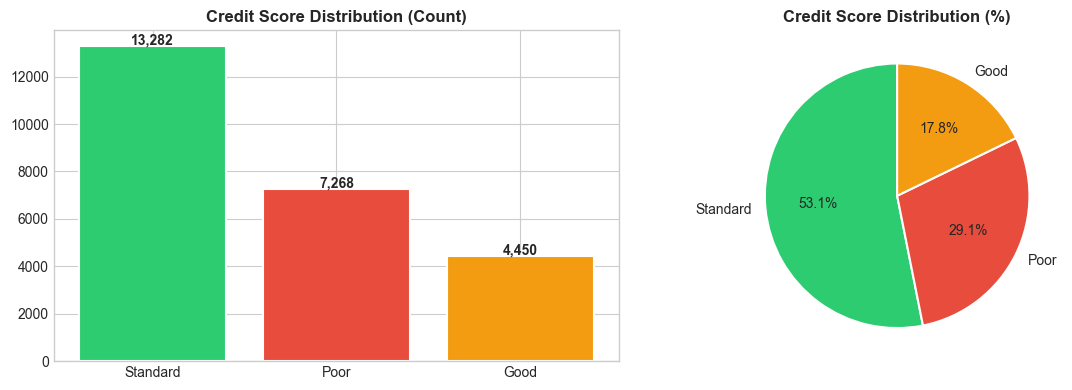

Credit_Score
Standard    13282
Poor         7268
Good         4450
Name: count, dtype: int64


In [5]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc = df['Credit_Score'].value_counts()
colors = ['#2ECC71', '#E74C3C', '#F39C12']

axes[0].bar(vc.index, vc.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Credit Score Distribution (Count)', fontweight='bold')
for i, (label, val) in enumerate(vc.items()):
    axes[0].text(i, val + 50, f'{val:,}', ha='center', fontweight='bold')

axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Credit Score Distribution (%)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(vc)

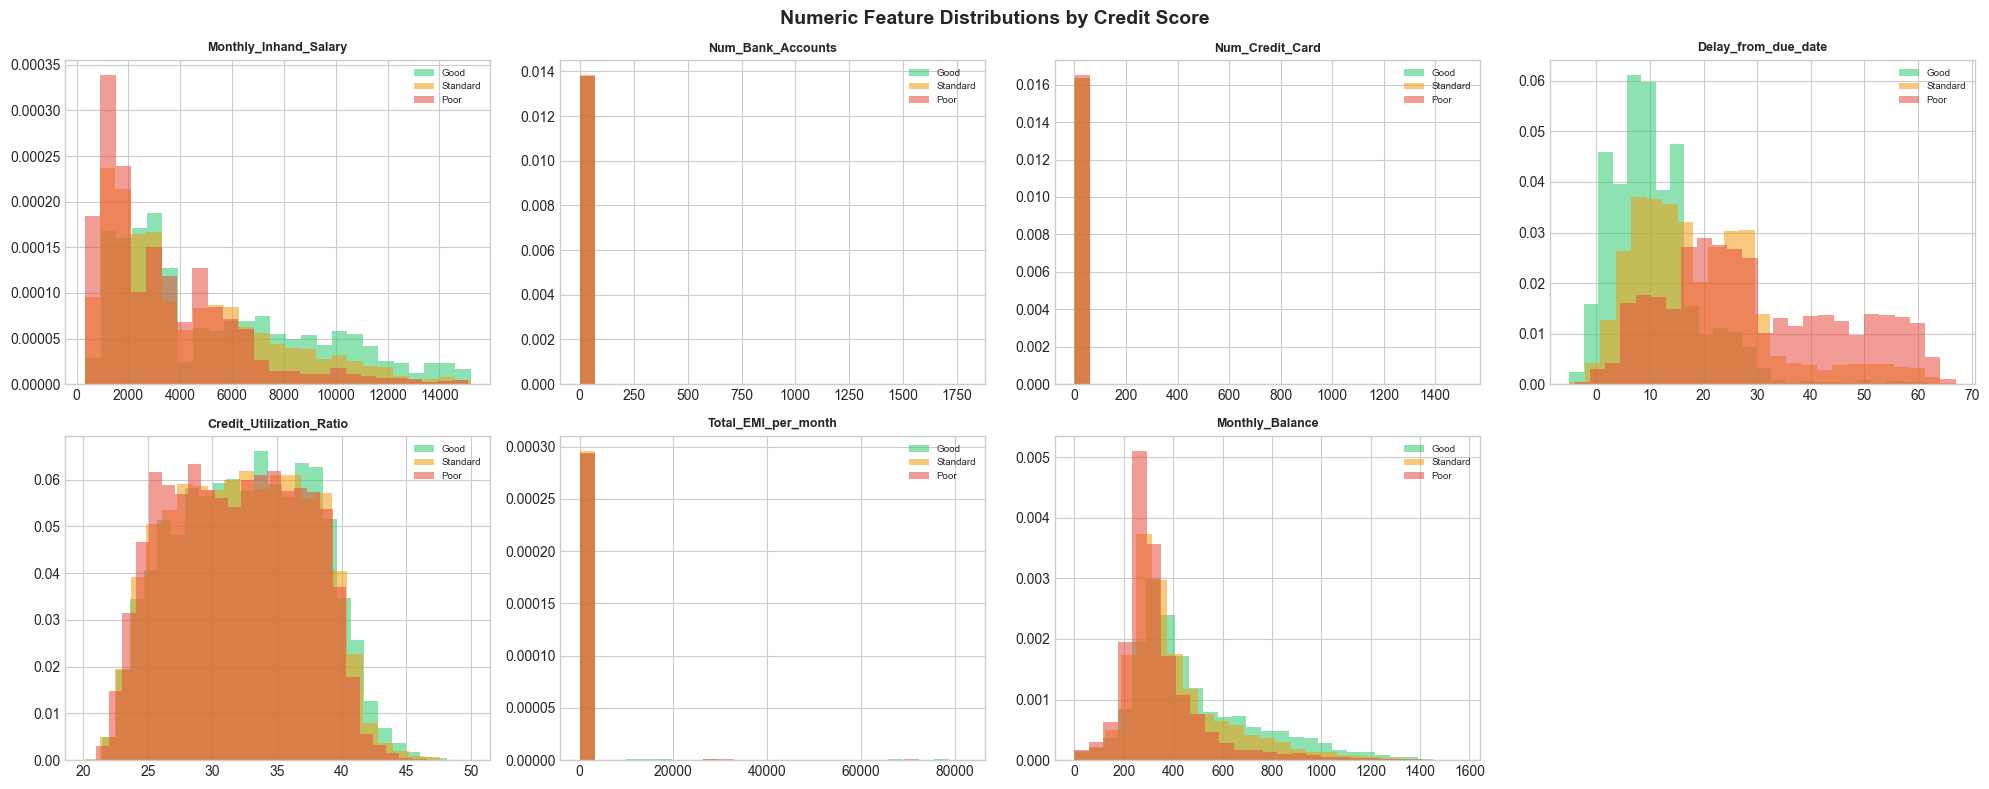

In [6]:
# Numeric feature distributions by Credit Score
numeric_feats = [
    'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
    'Delay_from_due_date', 'Credit_Utilization_Ratio',
    'Total_EMI_per_month', 'Monthly_Balance',
]
color_map = {'Good': '#2ECC71', 'Standard': '#F39C12', 'Poor': '#E74C3C'}

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flatten(), numeric_feats):
    for label, color in color_map.items():
        subset = df[df['Credit_Score'] == label][col]
        ax.hist(pd.to_numeric(subset, errors='coerce').dropna(),
                bins=25, alpha=0.55, color=color, label=label, density=True)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
axes.flatten()[-1].axis('off')
plt.suptitle('Numeric Feature Distributions by Credit Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

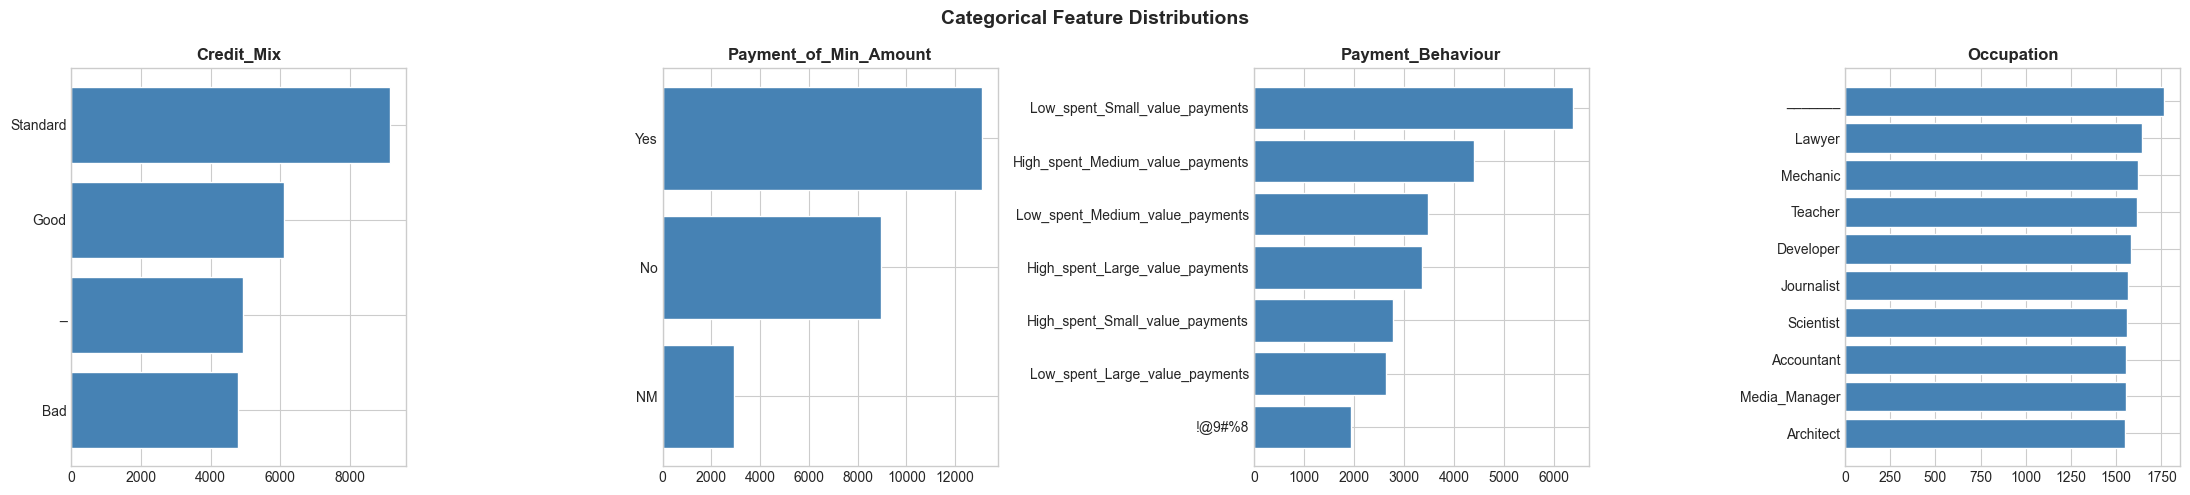

In [7]:
# Categorical feature distributions
cat_feats = ['Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Occupation']
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, col in zip(axes, cat_feats):
    vc2 = df[col].value_counts().head(10)
    ax.barh(vc2.index, vc2.values, color='steelblue', edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.invert_yaxis()
plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing

### Fitur yang Digunakan
Semua kolom kecuali identifier non-informatif: `Unnamed: 0`, `ID`, `Customer_ID`, `Name`, `SSN`, `Month`.

### Langkah Pre-processing
1. **Hapus kolom identifier** — tidak relevan untuk prediksi
2. **Bersihkan string numerik** — kolom seperti `Age`, `Annual_Income` mengandung karakter non-numerik (`_`, huruf)
3. **Parse `Credit_History_Age`** — konversi format 'X Years and Y Months' → total bulan
4. **Filter usia tidak wajar** — `Age` di luar 18–100 dihapus
5. **Imputasi numerik** — median imputation
6. **Imputasi kategorik** — mode imputation
7. **Scaling** — StandardScaler pada fitur numerik
8. **Encoding** — OrdinalEncoder pada fitur kategorik
9. **Label Encoding** — target `Credit_Score` → integer (0=Good, 1=Poor, 2=Standard)

In [8]:
preprocessor = Preprocessor()
X, y = preprocessor.fit_transform(df)
print(f'X shape: {X.shape}')
print(f'Classes: {list(preprocessor.label_encoder.classes_)}')
print(f'y distribution: {dict(zip(*np.unique(y, return_counts=True)))}')

X shape: (22828, 22)
Classes: ['Good', 'Poor', 'Standard']
y distribution: {0: 4274, 1: 6369, 2: 12185}


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (18262, 22)  |  Test: (4566, 22)


## 4. Model Training & Evaluation

### Metrik Evaluasi
| Metrik | Alasan Pemilihan |
|---|---|
| **Accuracy** | Proporsi prediksi benar secara keseluruhan |
| **F1 Weighted** | Utama — menangani class imbalance (Good < Standard < Poor) |
| **F1 Macro** | Per-class performance tanpa bobot jumlah |
| **Precision** | Kualitas prediksi positif |
| **Recall** | Kemampuan menemukan semua kasus |

### Eksperimen
5 algoritma diuji dengan hyperparameter default untuk menentukan baseline terbaik.

In [10]:
evaluator = Evaluator(preprocessor.label_encoder)

experiments = [
    LogisticRegressionTrainer(C=1.0, max_iter=500, solver='lbfgs'),
    DecisionTreeTrainer(max_depth=10, min_samples_split=5),
    RandomForestTrainer(n_estimators=200),
    GradientBoostingTrainer(n_estimators=150, learning_rate=0.1, max_depth=5),
    AdaBoostTrainer(n_estimators=100, learning_rate=0.5),
]

results = []
trained_models = {}

for trainer in experiments:
    print(f'\n{'─'*50}')
    print(f'  Model: {trainer.model_name}')
    print(f'{'─'*50}')
    model   = trainer.train(X_train, y_train)
    metrics = evaluator.evaluate(model, X_test, y_test)
    metrics['model'] = trainer.model_name
    results.append(metrics)
    trained_models[trainer.model_name] = model

results_df = pd.DataFrame(results).set_index('model').sort_values('f1', ascending=False)
print('\n=== Model Comparison (sorted by F1 Weighted) ===')
print(results_df.to_string())


──────────────────────────────────────────────────
  Model: logistic_regression
──────────────────────────────────────────────────

  Accuracy    : 0.6051
  F1 Weighted : 0.5885
  F1 Macro    : 0.5369
  Precision   : 0.6009
  Recall      : 0.6051

              precision    recall  f1-score   support

        Good       0.50      0.33      0.40       855
        Poor       0.65      0.44      0.52      1274
    Standard       0.61      0.79      0.69      2437

    accuracy                           0.61      4566
   macro avg       0.59      0.52      0.54      4566
weighted avg       0.60      0.61      0.59      4566


──────────────────────────────────────────────────
  Model: decision_tree
──────────────────────────────────────────────────

  Accuracy    : 0.6770
  F1 Weighted : 0.6762
  F1 Macro    : 0.6481
  Precision   : 0.6767
  Recall      : 0.6770

              precision    recall  f1-score   support

        Good       0.56      0.57      0.56       855
        Poor      

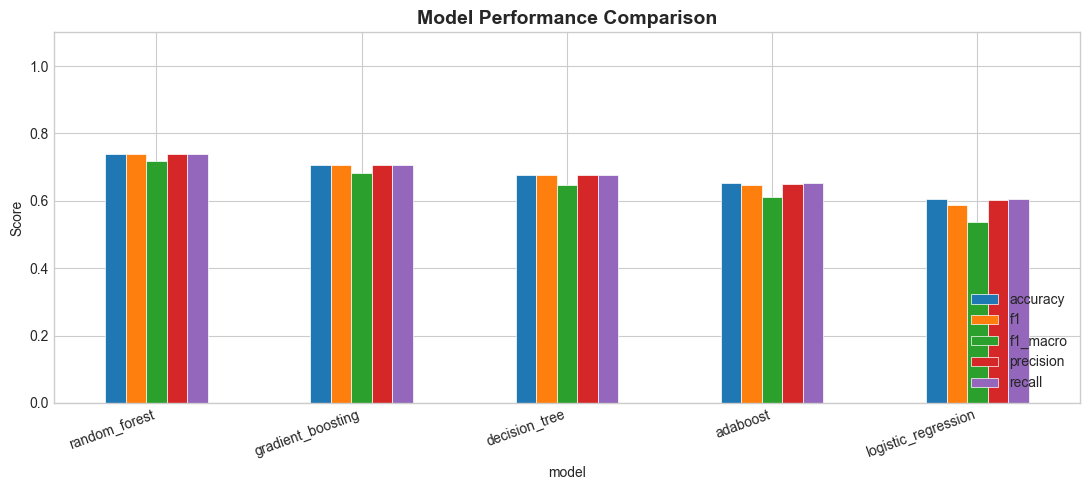

In [11]:
# Visualisasi perbandingan model
fig, ax = plt.subplots(figsize=(11, 5))
results_df[['accuracy', 'f1', 'f1_macro', 'precision', 'recall']].plot(
    kind='bar', ax=ax, edgecolor='white', linewidth=0.5
)
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=14)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right', framealpha=0.9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../outputs/04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

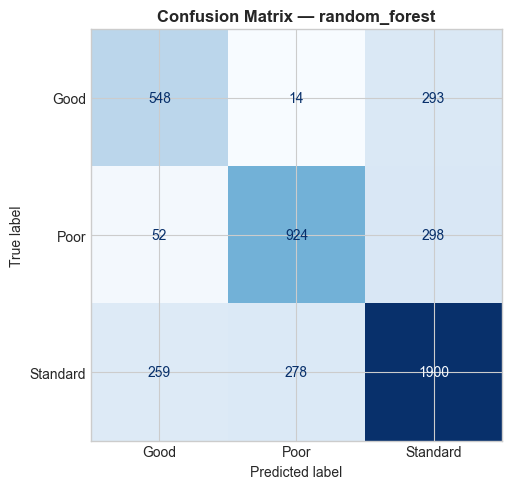

Best model: random_forest  (F1 Weighted = 0.7384)


In [12]:
# Confusion matrix – best model
best_name  = results_df.index[0]
best_model = trained_models[best_name]
y_pred     = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=preprocessor.label_encoder.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/05_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best model: {best_name}  (F1 Weighted = {results_df.loc[best_name, "f1"]:.4f})')

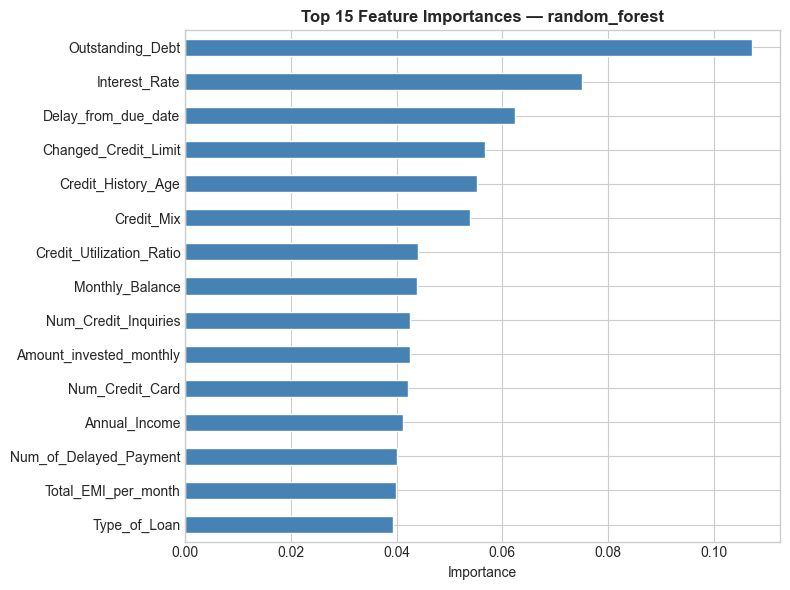

In [13]:
# Feature importance (if tree-based)
if hasattr(best_model, 'feature_importances_'):
    feat_names = preprocessor.num_features + preprocessor.cat_features
    fi = pd.Series(best_model.feature_importances_, index=feat_names).sort_values(ascending=True).tail(15)
    fig, ax = plt.subplots(figsize=(8, 6))
    fi.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Top 15 Feature Importances — {best_name}', fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('../outputs/06_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'{best_name} does not expose feature_importances_')

## 5. Save Best Model & Preprocessor

In [14]:
import joblib, os
os.makedirs('../models', exist_ok=True)

preprocessor.save('../models/preprocessor.pkl')
joblib.dump(best_model, '../models/best_model.pkl')
with open('../models/best_model_name.txt', 'w') as f:
    f.write(best_name)

print(f'✅ Saved: {best_name} → ../models/')

  [Preprocessor] saved → ../models/preprocessor.pkl
✅ Saved: random_forest → ../models/
